
# Lab1_4: PDE_capacitor

In [16]:
#Librery
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt

In [2]:
#up files from Drive
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
#Read
path = 'drive/MyDrive/Colab Notebooks/Fisica_Computacional_1/figures/'
filename3 = 'Laplace_df_3.png'
filename2 = 'Laplace_df_2.png'
filename4 = 'Laplace_df_4.png'
filename5 = 'Laplace_df_capacitor.png'

Mounted at /content/drive


### Potential and Electric field from a capacitor

####Lab1_4_PDE_capacitor:

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:

\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}
\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}

However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

* Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

* Compute numerically (use finite difference method) the electric field.

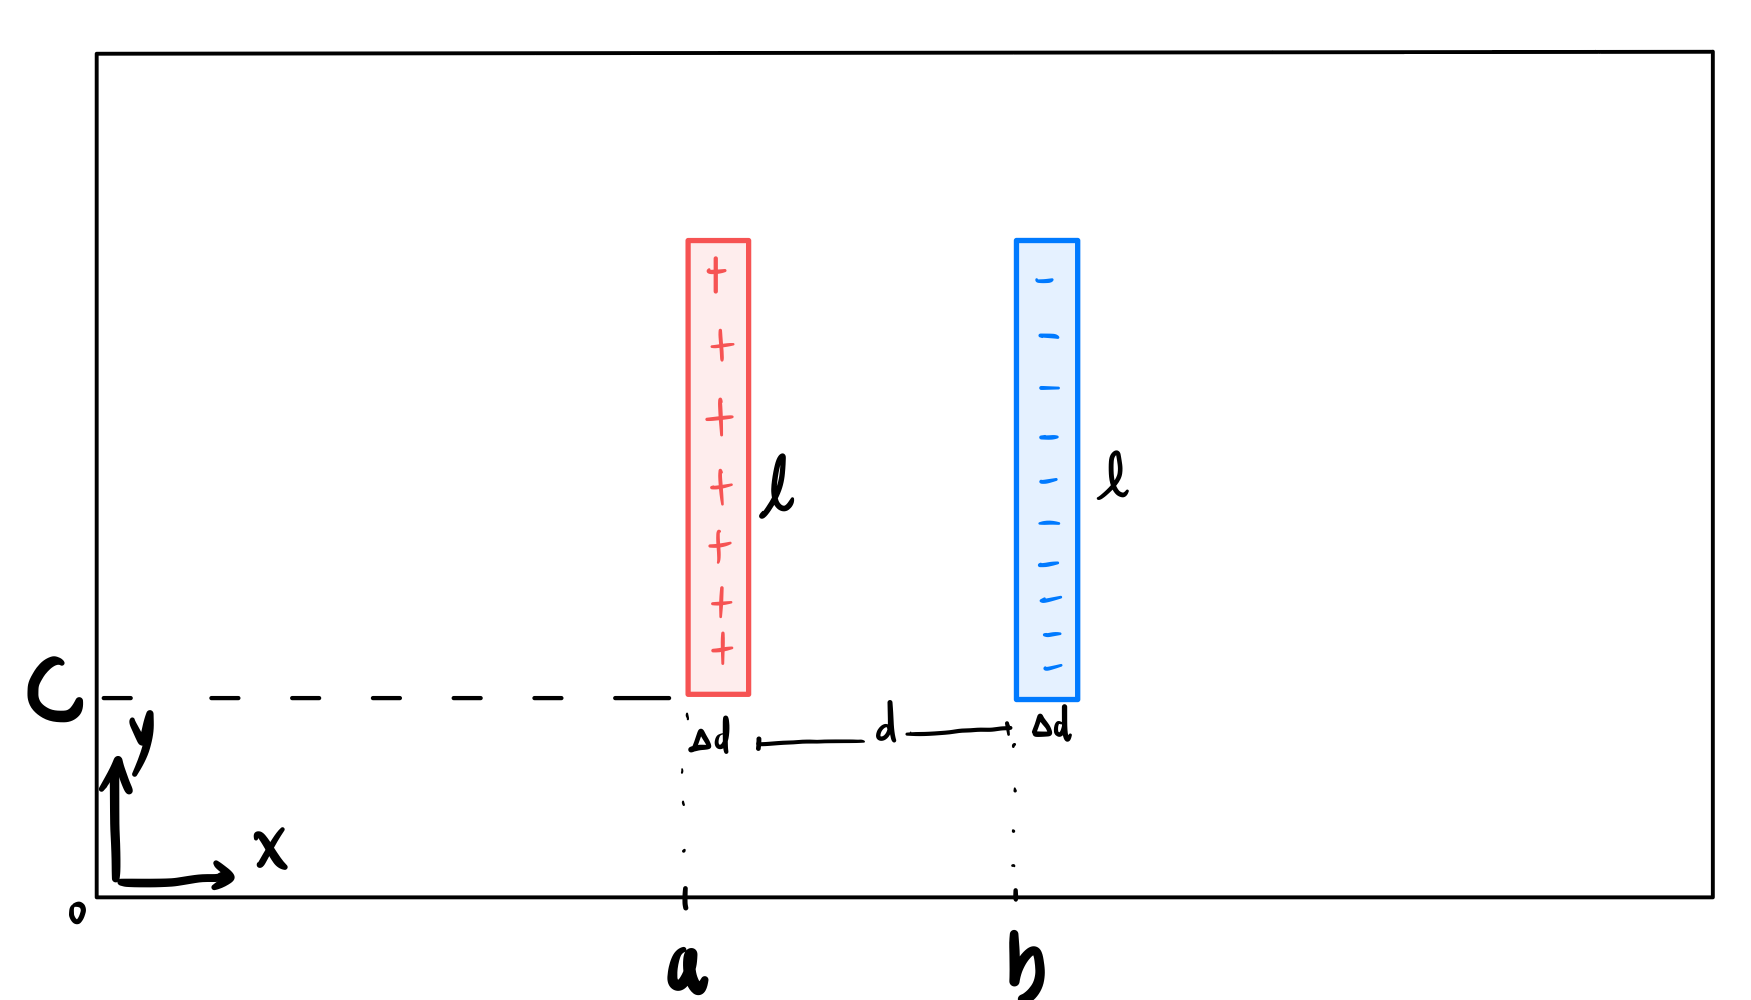

In [ ]:
from IPython.display import Image
Image(filename=path+filename5, width=500)

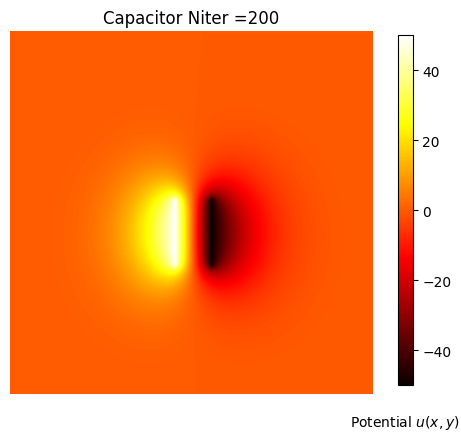

In [ ]:
# let's construc you own rutine. As an example:
from capacitor import capacitor_df #my rutine

# Plot imshow
Niter = 200
V = capacitor_df(Niter)
fig, ax = plt.subplots(figsize=(5,5) )
im = ax.imshow(V.copy(),cmap="hot",interpolation="bilinear",)
ax.set_axis_off()
ax.set_title('Capacitor Niter =%.1d'%Niter)

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("Potential $u(x,y)$", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

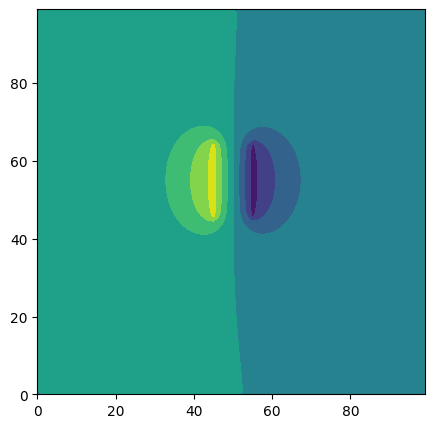

In [ ]:
plt.subplots(figsize=(5,5) )
plt.contourf(V)
plt.show()

#SOLUCION

In [17]:
# Parámetros
N = 100
V0 = 100
tol = 1e-4
max_iter = 10000

# Malla
V = np.zeros((N, N))
fixed = np.zeros_like(V, dtype=bool)

# Definir placas del capacitor pongo la placa superior como +V0, la inferior como -V0 y los bordes V como 0

# Coordenadas placas
y1 = int(N*0.3)
y2 = int(N*0.7)
x1 = int(N*0.3)
x2 = int(N*0.7)

# Placa inferior (-V0)
V[y1, x1:x2] = -V0
fixed[y1, x1:x2] = True

# Placa superior (+V0)
V[y2, x1:x2] = V0
fixed[y2, x1:x2] = True

In [19]:
for it in range(max_iter):
    V_nuevo = V.copy()

    for i in range(1, N-1):
        for j in range(1, N-1):
            if not fixed[i,j]:
                V_nuevo[i,j] = 0.25 * (
                    V[i+1,j] + V[i-1,j] +
                    V[i,j+1] + V[i,j-1]
                )

    error = np.max(np.abs(V_nuevo - V))

    if error < tol:
        print("Convergió en:", it)        #converge cuando max[V^(k+1)-V^(k)]<tol
        break

    V = V_nuevo.copy()


Convergió en: 0


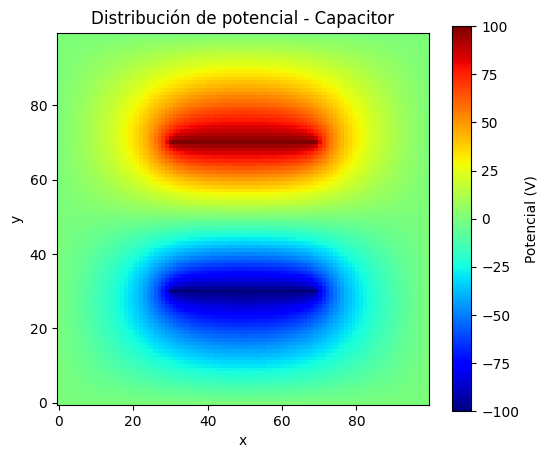

In [20]:
plt.figure(figsize=(6,5))
plt.imshow(V, origin='lower', cmap='jet')
plt.colorbar(label="Potencial (V)")
plt.title("Distribución de potencial - Capacitor")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

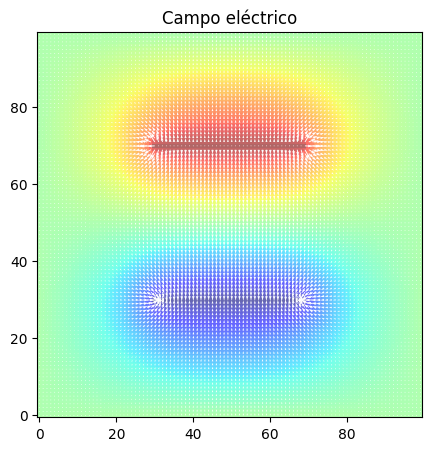

In [21]:
Ey, Ex = np.gradient(-V)

plt.figure(figsize=(6,5))
plt.imshow(V, origin='lower', cmap='jet', alpha=0.6)
plt.quiver(Ex, Ey, color='white')
plt.title("Campo eléctrico")
plt.show()
#El campo apunta de mayor a menor potencial y es perpendicular a la lineas o superficies equipotenciales